## **SINGLE SYSTEMS**

In [102]:
from qiskit import __version__
print(__version__)

2.3.0


In [103]:
import numpy as np 

ket0 = np.array([[1], [0]])
ket1 = np.array([[0], [1]])

print(ket0/2 + ket1/2)

[[0.5]
 [0.5]]


In [104]:
M1 = np.array([[1,1], [0,0]])
M2 = np.array([[1,0],[0,1]])
M = M1/2 + M2/2
print(M)

[[1.  0.5]
 [0.  0.5]]


In [105]:
#matriks multiplication
a = np.matmul(M1, ket1)         
b = np.matmul(M1, M2)
c = np.matmul(M, M)

print(a)
print(b)
print(c)

[[1]
 [0]]
[[1 1]
 [0 0]]
[[1.   0.75]
 [0.   0.25]]


In [106]:
from qiskit.visualization import array_to_latex

display(array_to_latex(a))
display(array_to_latex(b))
display(array_to_latex(c))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [107]:
from qiskit.quantum_info import Statevector

u = Statevector([1/np.sqrt(2), 1/np.sqrt(2)])
v = Statevector([(1+2.0j)/3, -2/3])
w = Statevector([1/3, 2/3])

In [108]:
display(u.draw('text'))
display(u.draw('latex'))
display(u.draw('latex_source'))

[0.70710678+0.j,0.70710678+0.j]

<IPython.core.display.Latex object>

'\\frac{\\sqrt{2}}{2} |0\\rangle+\\frac{\\sqrt{2}}{2} |1\\rangle'

In [109]:
display(v.draw('text'))
display(v.draw('latex'))
display(v.draw('latex_source'))

[ 0.33333333+0.66666667j,-0.66666667+0.j        ]

<IPython.core.display.Latex object>

'(\\frac{1}{3} + \\frac{2 i}{3}) |0\\rangle- \\frac{2}{3} |1\\rangle'

In [110]:
display(w.draw('text'))
display(w.draw('latex'))
display(w.draw('latex_source'))

[0.33333333+0.j,0.66666667+0.j]

<IPython.core.display.Latex object>

'\\frac{1}{3} |0\\rangle+\\frac{2}{3} |1\\rangle'

In [111]:
#which checks to see if a given vector is a valid quantum state vector
display(u.is_valid())
display(v.is_valid())
display(w.is_valid())

True

True

False

In [112]:
#simulating measureent using Statevector
display(v.draw('latex'))

<IPython.core.display.Latex object>

In [113]:
#mengembalikan hasil pengukuran, dan menambahkan vektor keadaan kuantum baru ke dalam sistem setelah pengukuran
outcome, state = v.measure()
print(f"Measured: {outcome}\nPost-measurement state:\n")
display(state.draw('latex'))        #hasilnya bakal beda2 setiap di run karena hasil pengukuran bersifat probabilistik

Measured: 1
Post-measurement state:



<IPython.core.display.Latex object>

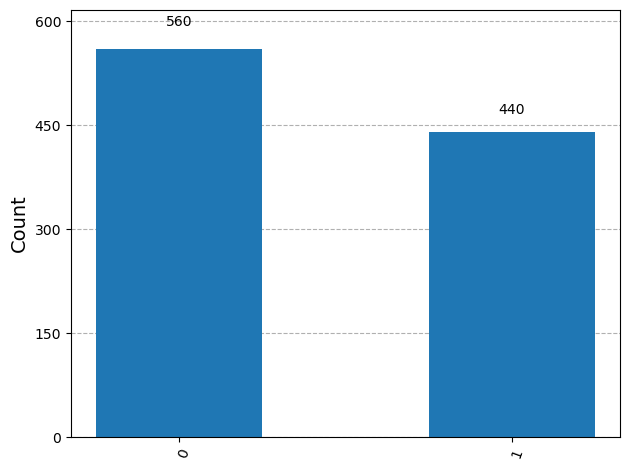

In [114]:
from qiskit.visualization import plot_histogram

statistics = v.sample_counts(1000)
plot_histogram(statistics)

In [115]:
#mendefinisikan operator uniter pake oprator class dari qiskit
from qiskit.quantum_info import Operator

Y = Operator([[0, -1.0j], [1.0j, 0]])
H = Operator([[1/np.sqrt(2), 1/np.sqrt(2)], [1/np.sqrt(2), -1/np.sqrt(2)]])
S = Operator([[1, 0], [0, 1.0j]])
T = Operator([[1, 0], [0, (1 + 1.0j)/np.sqrt(2)]])

display(T.draw("latex"))

<IPython.core.display.Latex object>

In [116]:
#aplikasikan operator uniter ke state vector pake evolve metode
v = Statevector([1,0])

v = v.evolve(H)
v = v.evolve(T)
v = v.evolve(H)
v = v.evolve(S)
v = v.evolve(Y)

display(v.draw('latex'))

<IPython.core.display.Latex object>

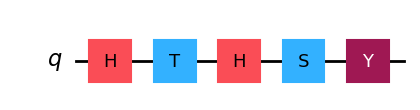

In [117]:
#menampilkan quantum circuit
from qiskit import QuantumCircuit
qc = QuantumCircuit(1)
qc.h(0)
qc.t(0)
qc.h(0)
qc.s(0)
qc.y(0)
display(qc.draw('mpl'))

In [118]:
#menampilkan quantum circuit pake latex
display(Operator.from_circuit(qc).draw('latex'))

<IPython.core.display.Latex object>

In [119]:
#menginisialisasi state vector kuantum awal dan kemudian mengembangkan keadaan sesuai dengan urutan operator yang diberikan dalam quantum circuit
ket0 = Statevector([1,0])
v = ket0.evolve(qc)
display(v.draw('latex'))

<IPython.core.display.Latex object>

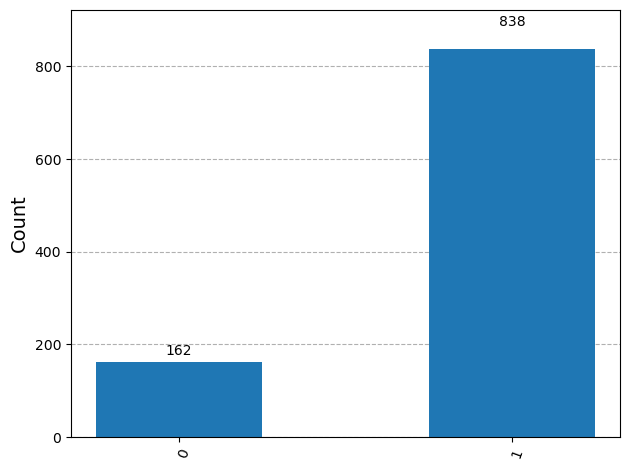

In [120]:
statistics = v.sample_counts(1000)
plot_histogram(statistics)

## **MULTIPLE SYSTEM**

In [121]:
from qiskit.quantum_info import Statevector, Operator
import numpy as np

### ***tensor product***

In [122]:
zero = Statevector.from_label('0')
one = Statevector.from_label('1')
psi = zero.tensor(one)
display(psi.draw('latex'))

<IPython.core.display.Latex object>

In [123]:
plus = Statevector.from_label('+')
minus_i = Statevector.from_label('l')
phi = plus.tensor(minus_i)
display(phi.draw('latex'))

<IPython.core.display.Latex object>

In [124]:
#bisa pake ^ buat tensor product juga
display((plus ^ minus_i).draw('latex'))

<IPython.core.display.Latex object>

In [125]:
#operator juga punya metode tensor product
H = Operator.from_label('H')
Id = Operator.from_label('I')
X = Operator.from_label('X')
Y = Operator.from_label('Y')
Z = Operator.from_label('Z')

display(H.tensor(Id).draw('latex'))
display(H.tensor(Id).tensor(X).draw('latex'))
display(H.tensor(Id).tensor(Y).draw('latex'))
display(H.tensor(Id).tensor(Z).draw('latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [126]:
display((H^Id^X).draw('latex'))

<IPython.core.display.Latex object>

In [127]:
display((phi.evolve(H^Id).draw('latex')))

<IPython.core.display.Latex object>

In [128]:
#kode yg sama, tapi pake CX operator dan menghitung CX|PSI> untuk |PSI> = |+>^|0>. Jelasnya, CX qubit kiri adalah kontrol dan qubit kanan adalah target
CX = Operator([[1,0,0,0], [0,1,0,0], [0,0,0,1], [0,0,1,0]])
psi = (plus ^ zero)
display(psi.evolve(CX).draw('latex'))

<IPython.core.display.Latex object>

#### ***partial measurement***
secara default, mengukur semua state qubit vector. Sebagai alternatif, dapat memberikan daftar bilangan ulat sebagai argumen, yang hanya menyebabkan indeks qubit tersebut diukur. sehingga, menciptakan keadaan:

In [101]:
w = Statevector([0,1,1,0,1,0,0,0]/np.sqrt(3))
display(w.draw('latex'))

result, state = w.measure([0])
print(f"Measured: {result}\nState after measurement:")
display(state.draw('latex'))

result, state = w.measure([0,1])
print(f"Measured: {result}\nState after measurement:")
display(state.draw('latex'))

<IPython.core.display.Latex object>

Measured: 0
State after measurement:


<IPython.core.display.Latex object>

Measured: 10
State after measurement:


<IPython.core.display.Latex object>

## **ENTANGLEMENT IN ACTION**

In [129]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

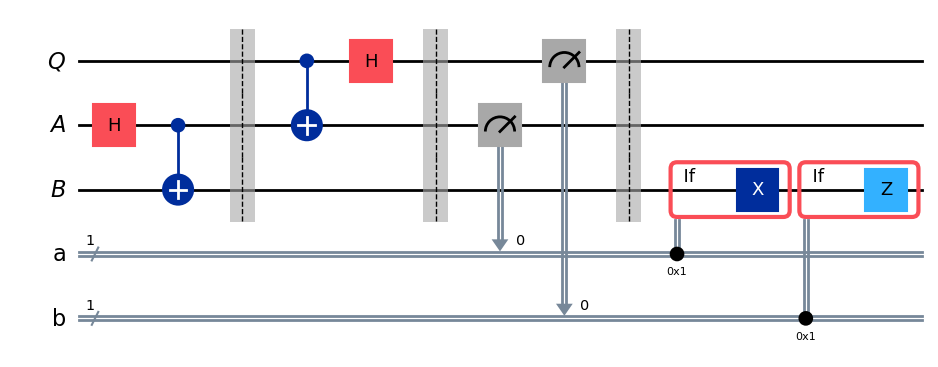

In [130]:
#implementasi quantum circuit untuk protocol teleportasi kuantum, yang memungkinkan untuk mentransfer keadaan kuantum dari satu lokasi ke lokasi lain tanpa memindahkan partikel fisik yang membawa keadaan tersebut.
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

#menyiapkan ebit untuk teleportasi
protocol.h(ebit0[0])
protocol.cx(ebit0, ebit1)
protocol.barrier()

#operator alice
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

#pengukuran alice dan mengirim hasilnya ke bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

#bob melakukan operasi koreksi berdasarkan hasil pengukuran alice
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw('mpl'))

Circuit pertama kali menginisialisasi (A,B) untuk berada di keadaan $ |\phi+> $ (yang dimana bukan bagian dari protocol), mengikuti pengukuran operator Alice, dan terakhir operator Bob. untuk menguji apakah protocol bekerja dengan benar, kita mengaplikasikan single qubit gate untuk menginisialisasi $ |0> $ state of Q untuk mendapatkan random quantum state vector to be telported. dengan mengaplikasikan invers (conjugate transpose) of that gate to B setelah protocolnya berjalan. kita dapan memverifikasi keadaanya sudah teleportasi dengan pengukuran dan melihat apakah sudah berganti ke $ |0> $ state

In [131]:
#pertama, randomly memilih unitary qubit gate
random_gate = UGate(
    theta=random.random()*2*pi,
    phi=random.random()*2*pi,
    lam=random.random()*2*pi
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

In [ ]:
#membuat circuit baru